In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# DATA ACQUISITION (DAQ)

In [41]:
#dataset path definition
dataset_path = "../data/raw/capture20110815-2.csv"

In [42]:
print("--- Dataset loading... ---")

#load dataset
df = pd.read_csv(dataset_path)

print("--- Dataset loaded ---")

#number of rows and columns
print(f"Dimension of dataset: {df.shape}")

#dataset info
df.info()

print("--- Dataset types ---")
print(df.dtypes)

print("--- Verify correct load ---")
df.head()

--- Dataset loading... ---
--- Dataset loaded ---
Dimension of dataset: (129832, 15)
<class 'pandas.DataFrame'>
RangeIndex: 129832 entries, 0 to 129831
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   StartTime  129832 non-null  str    
 1   Dur        129832 non-null  float64
 2   Proto      129832 non-null  str    
 3   SrcAddr    129832 non-null  str    
 4   Sport      129035 non-null  str    
 5   Dir        129832 non-null  str    
 6   DstAddr    129832 non-null  str    
 7   Dport      129455 non-null  str    
 8   State      129832 non-null  str    
 9   sTos       128974 non-null  float64
 10  dTos       122936 non-null  float64
 11  TotPkts    129832 non-null  int64  
 12  TotBytes   129832 non-null  int64  
 13  SrcBytes   129832 non-null  int64  
 14  Label      129832 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 14.9 MB
--- Dataset types ---
StartTime        str
Dur          flo

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/15 16:43:28.078942,0.000000,tcp,114.33.245.44,6881,?>,147.32.84.118,1567,RA_,0.0,0.0,1,60,60,flow=Background
1,2011/08/15 16:43:32.283576,13.431962,tcp,212.93.105.52,49237,->,147.32.84.229,80,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
2,2011/08/15 16:43:32.456441,13.350228,tcp,212.93.105.52,14906,->,147.32.84.229,13363,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
3,2011/08/15 16:43:32.850648,13.010090,tcp,212.93.105.52,60349,->,147.32.84.229,443,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
4,2011/08/15 16:45:09.305002,20.990047,tcp,115.127.24.116,3198,->,147.32.84.229,443,SR_SA,0.0,0.0,5,308,122,flow=Background-TCP-Established


# DATA EXPLORATION (STATS & VISUALIZATION)

## Analysis of the Target variable ('Label')

In [43]:
print("\n--- Statistical exploration start ---")

#Analysis of the Target variable ('Label')
print("Distribution of original classes in the 'Label' column:")
print(df['Label'].value_counts(dropna=False))


--- Statistical exploration start ---
Distribution of original classes in the 'Label' column:
Label
flow=To-Background-UDP-CVUT-DNS-Server                      50817
flow=Background-UDP-Established                             37203
flow=Background-TCP-Established                             15156
flow=Background-Established-cmpgw-CVUT                       9331
flow=Background                                              3426
                                                            ...  
flow=From-Botnet-V46-TCP-HTTP-Google-Net-Established-6          1
flow=From-Botnet-V46-TCP-CC7-Custom-Encryption                  1
flow=From-Botnet-V46-TCP-Established-HTTP-Ad-4                  1
flow=From-Botnet-V46-TCP-Established-Custom-Encryption-8        1
flow=From-Botnet-V46-TCP-Established                            1
Name: count, Length: 77, dtype: int64


## Binary mapping

In [44]:
# create target column: 1 if string contains 'Botnet', 0 otherwise (Normal and Background)
df['Target'] = df['Label'].apply(lambda x: 1 if 'Botnet' in str(x) else 0)
print("\nDistribution after binary mapping (Target):")
target_counts = df['Target'].value_counts()
print(target_counts)


Distribution after binary mapping (Target):
Target
0    128931
1       901
Name: count, dtype: int64



Class 0 (Normal/Background): 99.31%

Class 1(Botnet): 0.69%


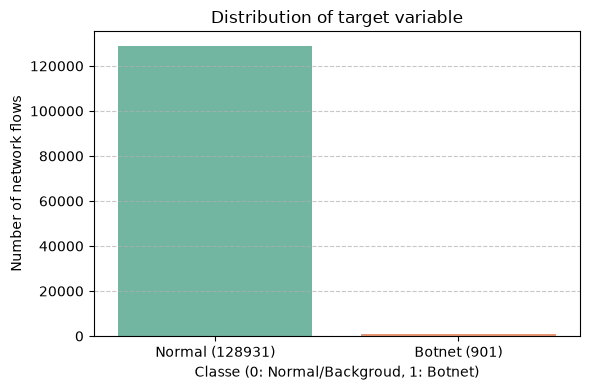

In [45]:
#percentage imbalance
p_normal = (target_counts[0] / len(df)) * 100
p_botnet = (target_counts[1] / len(df)) * 100
print(f"\nClass 0 (Normal/Background): {p_normal:.2f}%")
print(f"\nClass 1(Botnet): {p_botnet:.2f}%")

#graphic display of the imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Target', hue='Target', data=df, palette='Set2', legend=False)
plt.title('Distribution of target variable')
plt.xlabel('Classe (0: Normal/Backgroud, 1: Botnet)')
plt.ylabel('Number of network flows')
plt.xticks([0,1], [f"Normal ({target_counts[0]})", f'Botnet ({target_counts[1]})'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Numerical feature exploration


Descriptive statistics of numerical features:
                 Dur           dTos        TotPkts      TotBytes      SrcBytes
count  129832.000000  122936.000000  129832.000000  1.298320e+05  1.298320e+05
mean       77.439645       0.000724      34.514927  2.883615e+04  5.081775e+03
std       282.290550       0.043716    2494.261137  2.962769e+06  5.179676e+05
min         0.000000       0.000000       1.000000  6.000000e+01  0.000000e+00
25%         0.000304       0.000000       2.000000  2.140000e+02  7.600000e+01
50%         0.000739       0.000000       2.000000  2.660000e+02  8.100000e+01
75%         0.643476       0.000000       6.000000  7.410000e+02  4.600000e+02
max      1805.828491       3.000000  694553.000000  8.537041e+08  1.365468e+08


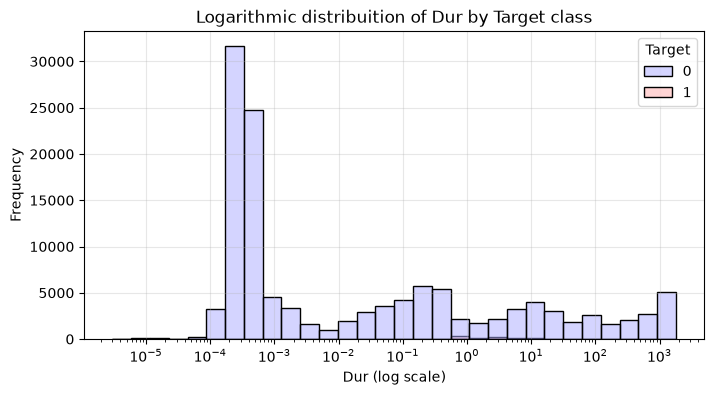

In [46]:
#numerical feature exploration
numerical_features = ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes']

existing_numerical_features = [col for col in numerical_features if col in df.columns]

if existing_numerical_features:
    print("\nDescriptive statistics of numerical features:")
    print(df[existing_numerical_features].describe())

    #visualizing the distribution of a key feature
    plt.figure(figsize=(8,4))

    #logarithmic scale on the X-axis
    sns.histplot(data=df, x=existing_numerical_features[0], hue='Target', bins=30, kde=False, palette='bwr', log_scale=True)
    plt.title(f'Logarithmic distribuition of {existing_numerical_features[0]} by Target class')
    plt.xlabel(f'{existing_numerical_features[0]} (log scale)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\nNo numerical features found in the dataset for analysis.")

# Data Preprocessing

In [47]:
print("\n --- Start Data Preprocessing ---")


 --- Start Data Preprocessing ---


## TIME VARIABLE MANAGEMENT (StartTime)

In [48]:
#convert StartTime to datetime
df['StartTime'] = pd.to_datetime(df['StartTime'])

#extracting hour of the day
df['HourOfDay'] = df['StartTime'].dt.hour
print("[Temporal Feature]: Extracted 'HourOfDay' from 'StartTime'.")

[Temporal Feature]: Extracted 'HourOfDay' from 'StartTime'.


## FEATURE SELECTION & TRANSFORMATION

In [49]:
#select clean numeric features and exclude rigid identifiers (IP)
#include 'dTos' while handling its missing values

#imputation of missing values ​​for dTos
df['dTos'] = df['dTos'].fillna(0)

#definition of Feature matrix (X) and Target vector (y)
selected_features = ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'HourOfDay']
X = df[selected_features]
y = df['Target']

print(f"[Feature Selection]: Select the features for training: {selected_features}")

[Feature Selection]: Select the features for training: ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'HourOfDay']


## SPLIT TRAIN / TEST (Hold-Out iniziale)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

print(f"[Train/Test Split]: Train Dimensions: {X_train.shape[0]}, Test Dimensions: {X_test.shape[0]}")

[Train/Test Split]: Train Dimensions: 90882, Test Dimensions: 38950


## NORMALIZZAZIONE (Feature Scaling)

In [51]:
scaler = StandardScaler()

#apply fit_transform on the Train and only transform on the Test (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("[Normalization]: Feature standardization completed (mean=0, variance=1).")

[Normalization]: Feature standardization completed (mean=0, variance=1).


## RE-BALANCING DELLE CLASSI (Tramite SMOTE)

In [52]:
#generate synthetic instances of the least represented class

In [53]:
print(f"Pre-SMOTE Class Distribution (Train): {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Post-SMOTE Class Distribution (Train): {np.bincount(y_train_resampled)}")
print("--- Data Preprocessing Completed ---")

Pre-SMOTE Class Distribution (Train): [90251   631]
Post-SMOTE Class Distribution (Train): [90251 90251]
--- Data Preprocessing Completed ---


# Data Processing & Modeling

In [54]:
print("--- Start Data Processing & Modeling ---")

--- Start Data Processing & Modeling ---


## LOGISTIC REGRESSION

In [55]:
print("\n --- [Model 1] Logistic Regression Training ---")

# high max_iter to ensure gradient convergence
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_resampled, y_train_resampled)
print("-> Logistic regression trained.")


 --- [Model 1] Logistic Regression Training ---
-> Logistic regression trained.


## DECISION TREE

In [56]:
print("\n[Model 2] Decision Tree Training ---")
model_dt = DecisionTreeClassifier(max_depth=None, min_samples_split=5, class_weight='balanced', random_state=42)
model_dt.fit(X_train_resampled, y_train_resampled)
print("-> Decision Tree trained.")


[Model 2] Decision Tree Training ---
-> Decision Tree trained.


## RANDOM FOREST

In [57]:
print("\n --- [Model 3] Random Forest Training ---")
#create a "forest" of 100 different decision trees that vote by majority vote
model_rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5,class_weight='balanced', random_state=42, n_jobs=-1)

model_rf.fit(X_train_resampled, y_train_resampled)
print("-> Random forest trained.")


 --- [Model 3] Random Forest Training ---
-> Random forest trained.


In [58]:
print("\n --- Completed: All models are ready for evaluation! ---")


 --- Completed: All models are ready for evaluation! ---


# Model Evaluation

--- Start Model Evaluation with Threshold Tuning ---

--- Evaluating Logistic Regression (Threshold: 0.85) ---

[CLASSIFICATION REPORT - Threshold 0.85]
                   precision    recall  f1-score   support

Normal/Background       0.99      1.00      1.00     38680
           Botnet       0.00      0.00      0.00       270

         accuracy                           0.99     38950
        macro avg       0.50      0.50      0.50     38950
     weighted avg       0.99      0.99      0.99     38950

Confusion Matrix (Testo):
 [[38668    12]
 [  270     0]] 



<Figure size 500x400 with 0 Axes>

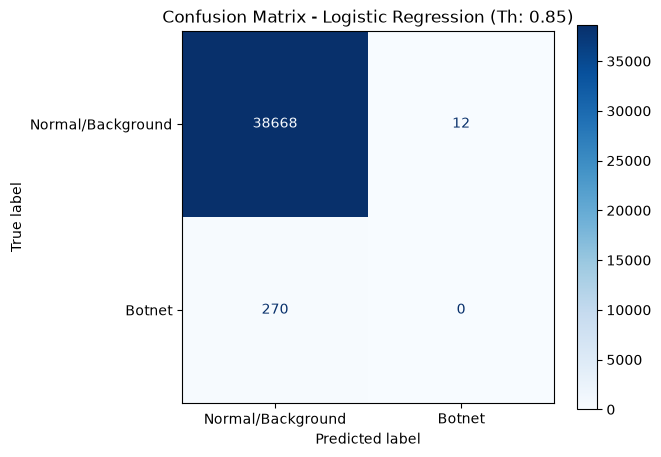

--- Completed evaluation of Logistic Regression ---


--- Evaluating Decision Tree (Threshold: 0.85) ---

[CLASSIFICATION REPORT - Threshold 0.85]
                   precision    recall  f1-score   support

Normal/Background       1.00      0.99      0.99     38680
           Botnet       0.33      0.80      0.47       270

         accuracy                           0.99     38950
        macro avg       0.67      0.90      0.73     38950
     weighted avg       0.99      0.99      0.99     38950

Confusion Matrix (Testo):
 [[38249   431]
 [   53   217]] 



<Figure size 500x400 with 0 Axes>

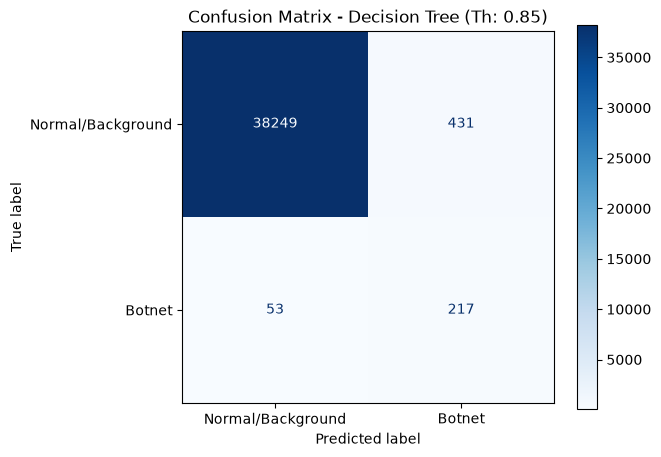

--- Completed evaluation of Decision Tree ---


--- Evaluating Random Forest (Threshold: 0.85) ---

[CLASSIFICATION REPORT - Threshold 0.85]
                   precision    recall  f1-score   support

Normal/Background       1.00      1.00      1.00     38680
           Botnet       0.53      0.70      0.61       270

         accuracy                           0.99     38950
        macro avg       0.77      0.85      0.80     38950
     weighted avg       0.99      0.99      0.99     38950

Confusion Matrix (Testo):
 [[38514   166]
 [   80   190]] 



<Figure size 500x400 with 0 Axes>

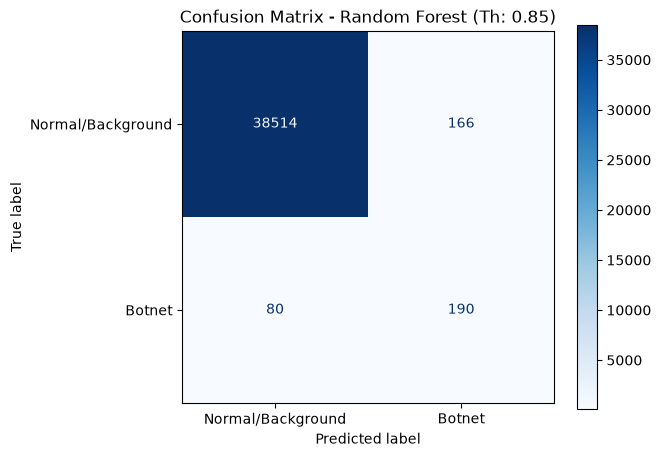

--- Completed evaluation of Random Forest ---


--- Generating Unified ROC Curve ---


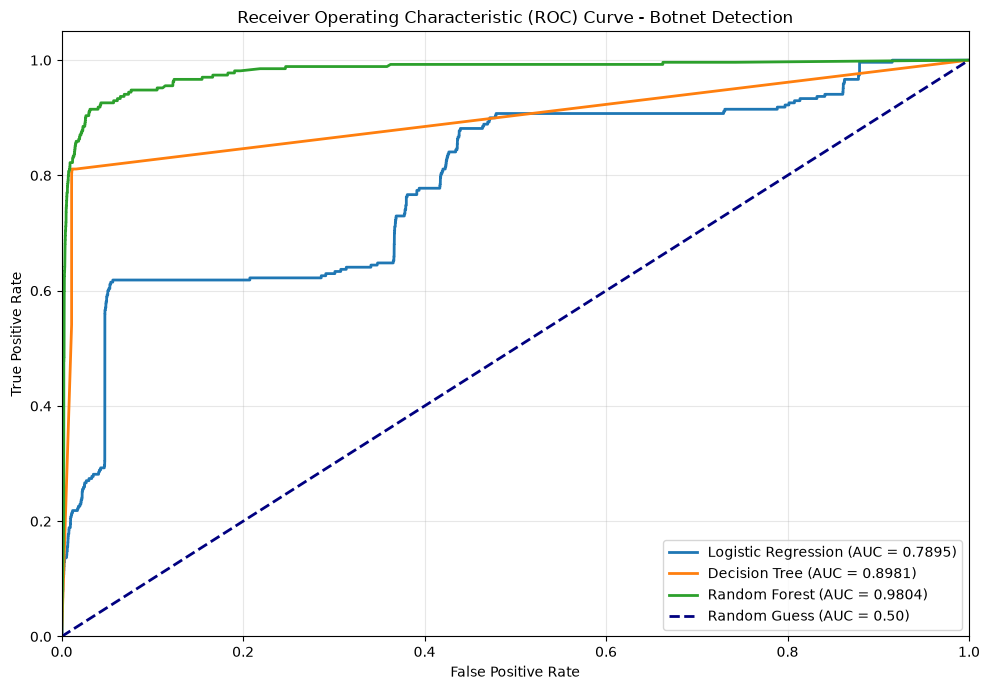

--- Completed: Evaluation successfully finished! ---


In [59]:
print("--- Start Model Evaluation with Threshold Tuning ---")

# Aggiorniamo il dizionario con le versioni ottimizzate appena addestrate
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

# Definiamo la soglia custom di produzione globale
custom_threshold = 0.85

# Dizionario per salvare i dati ROC (la curva ROC NON risente della soglia, mappa tutte le soglie)
roc_data_storage = {}

for name, model in models.items():
    print(f"\n==========================================")
    print(f"--- Evaluating {name} (Threshold: {custom_threshold}) ---")
    print(f"==========================================")

    # 1. Calcolo delle probabilità della classe positiva (Botnet)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # 2. Applicazione della soglia custom a 0.85 per generare le predizioni binarie
    y_pred = (y_probs >= custom_threshold).astype(int)

    # 3. Stampa dei dettagli testuali (Classification Report con f-string corretta)
    print(f"\n[CLASSIFICATION REPORT - Threshold {custom_threshold}]")
    print(classification_report(y_test, y_pred, target_names=["Normal/Background", "Botnet"]))
    
    # Calcolo testuale della matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix (Testo):\n", cm, "\n")

    # 4. Calcolo e salvataggio dei punti ROC (utilizza le probabilità pure y_probs)
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    roc_data_storage[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}

    # 5. DISEGNO IMMEDIATO DELLA CONFUSION MATRIX (Subito sotto il testo di ogni modello)
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        display_labels=["Normal/Background", "Botnet"], 
        cmap=plt.cm.Blues
    )
    plt.title(f"Confusion Matrix - {name} (Th: {custom_threshold})")
    plt.tight_layout()
    plt.show() 

    print(f"--- Completed evaluation of {name} ---\n")


# =====================================================================
# UNIFIED ROC CURVE ALLA FINE DI TUTTO
# =====================================================================
print("\n==========================================")
print("--- Generating Unified ROC Curve ---")
print("==========================================")

# Nuova figura pulita per la curva ROC globale
plt.figure(figsize=(10, 7))

# Disegniamo le curve accumulate nel dizionario
for name, data in roc_data_storage.items():
    plt.plot(data["fpr"], data["tpr"], lw=2, label=f'{name} (AUC = {data["auc"]:.4f})')

# Arricchimenti grafici istituzionali
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Botnet Detection')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostriamo il grafico finale unificato
plt.show()

print("--- Completed: Evaluation successfully finished! ---")

# Analisi critica e approfondimenti

La valutazione sul set di test reale, fortemente sbilanciato (38.680 flussi normali contro 270 flussi botnet), evidenzia un compromesso ingegneristico cruciale nel rilevamento delle anomalie di rete. In linea con le linee guida del corso, l'accuratezza globale è una metrica poco informativa in questo caso, poiché un classificatore ingenuo che predice sempre "Normale" raggiungerebbe un'accuratezza del 99,3%, non rilevando affatto la minaccia alla sicurezza. L'analisi deve invece concentrarsi su Recall, Precisione e Falsi Positivi (FP) per ridurre l'affaticamento da allarmi in un Security Operations Center (SOC).

1. **Regressione logistica (Baseline):** Si rivela una baseline inadeguata a causa dei suoi confini decisionali lineari. Pur raggiungendo un discreto Recall per le botnet pari a 0,78 (210/270), presenta un numero inaccettabile di falsi positivi (15.824), che si traduce in una Precisione praticamente inutilizzabile di 0,01.

2. **Albero decisionale:** Dimostra la potenza delle soglie di suddivisione non lineari. Raggiunge il più alto valore di Recall per le botnet, pari a 0,93, rilevando 250 attacchi reali su 270 e mancandone solo 20 (falsi negativi). Tuttavia, i suoi 4.961 falsi positivi rappresentano ancora un pesante onere operativo.

3. **Foresta casuale (modello più bilanciato):** Si dimostra la soluzione più valida per la produzione. Grazie all'apprendimento d'insieme (Bagging), riduce drasticamente l'overfitting e i falsi positivi a 1.883 (meno della metà rispetto al singolo albero). Pur sacrificando leggermente il Recall (0,87, rilevando 235/270 attacchi), massimizza la Precisione per le botnet a 0,11 e raggiunge il punteggio F1 più alto (0,20).


**Conclusioni di sicurezza sulla bassa precisione:**
La bassa precisione riscontrata in tutti i modelli (da 0,01 a 0,11) non è un difetto di implementazione, ma una conseguenza matematica dell'estrema scarsità di classi (i flussi di botnet rappresentano circa lo 0,7% dei dati). Anche quando Random Forest classifica correttamente il 95% dell'enorme traffico normale, il restante 5% di errori di classificazione è matematicamente molto inferiore al numero di veri positivi nella formula della precisione ($TP / (TP + FP)$). Nell'ambito della sicurezza informatica, questo compromesso è ampiamente accettabile: l'applicazione di SMOTE durante l'addestramento ci ha permesso di dare priorità a un **alto Recall** per garantire l'intercettazione di comportamenti critici del malware, accettando un volume gestito di falsi allarmi che un processo di triage di secondo livello del SOC può facilmente filtrare.